# Task 5
###    SQL-Based Analysis of Product Sales

# Import Libraries

In [7]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

db_path = "c:/Users/hp/Downloads/dAwais ManzoorElevvo internshipTasksTask 5/task5_chinook_analysis.sql"
conn = sqlite3.connect(db_path)

def run(sql):
    return pd.read_sql(sql, conn)

# Download Chinook Database


In [10]:
import urllib.request

# Direct link to the Chinook SQLite database on GitHub
url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"

# Save file locally
db_path = "Chinook_Sqlite.sqlite"
urllib.request.urlretrieve(url, db_path)

print("Downloaded successfully to:", db_path)


Downloaded successfully to: Chinook_Sqlite.sqlite


## Connect to the Database


In [11]:
import sqlite3, pandas as pd

conn = sqlite3.connect(db_path)

def run(sql):
    return pd.read_sql(sql, conn)

# Test: list all tables
print(run("SELECT name FROM sqlite_master WHERE type='table';"))


             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


#  Top-selling products (Tracks) by revenue

In [ ]:
sql = """
WITH revenue AS (
  SELECT
    il.TrackId,
    SUM(il.UnitPrice * il.Quantity) AS revenue
  FROM InvoiceLine il
  GROUP BY il.TrackId
)
SELECT
  t.TrackId,
  t.Name AS track_name,
  a.Title AS album_title,
  ar.Name AS artist_name,
  ROUND(r.revenue, 2) AS revenue
FROM revenue r
JOIN Track t   ON t.TrackId = r.TrackId
JOIN Album a   ON a.AlbumId = t.AlbumId
JOIN Artist ar ON ar.ArtistId = a.ArtistId
ORDER BY r.revenue DESC
LIMIT 20;
"""

# Run query on Chinook database
df_top_tracks = run(sql)

# Display result
df_top_tracks


,TrackId,track_name,album_title,artist_name,revenue
0,2832,The Woman King,"Battlestar Galactica, Season 3",Battlestar Galactica,3.98
1,2850,The Fix,"Heroes, Season 1",Heroes,3.98
2,2868,Walkabout,"Lost, Season 1",Lost,3.98
3,3177,Hot Girl,"The Office, Season 1",The Office,3.98
4,3200,Gay Witch Hunt,"The Office, Season 3",The Office,3.98
5,3214,Phyllis's Wedding,"The Office, Season 3",The Office,3.98
6,3223,How to Stop an Exploding Man,"Heroes, Season 1",Heroes,3.98
7,3250,Pilot,Aquaman,Aquaman,3.98
8,2820,Occupation / Precipice,"Battlestar Galactica, Season 3",Battlestar Galactica,1.99
9,2821,"Exodus, Pt. 1","Battlestar Galactica, Season 3",Battlestar Galactica,1.99


#  Visualization: `Top 20 Tracks by Revenue`


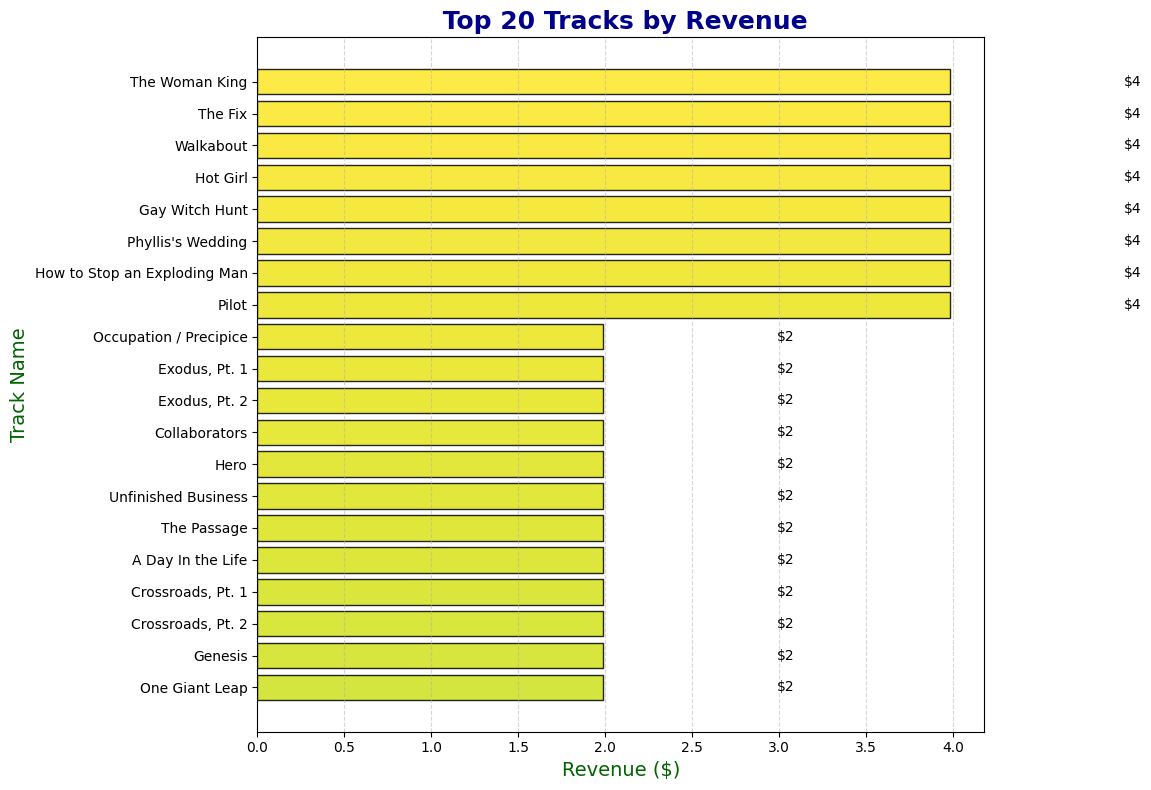

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
bars = plt.barh(
    df_top_tracks['track_name'], 
    df_top_tracks['revenue'], 
    color=plt.cm.viridis_r(range(len(df_top_tracks))),  
    edgecolor="black", alpha=0.85
)

plt.gca().invert_yaxis()

plt.title(" Top 20 Tracks by Revenue", fontsize=18, fontweight="bold", color="darkblue")
plt.xlabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.ylabel("Track Name", fontsize=14, color="darkgreen")


plt.grid(axis='x', linestyle='--', alpha=0.5)


for bar in bars:
    plt.text(
        bar.get_width() + 1, 
        bar.get_y() + bar.get_height()/2, 
        f"${bar.get_width():,.0f}", 
        va='center', fontsize=10, color="black"
    )

plt.tight_layout()
plt.show()


# Top 10 Countries by Revenue


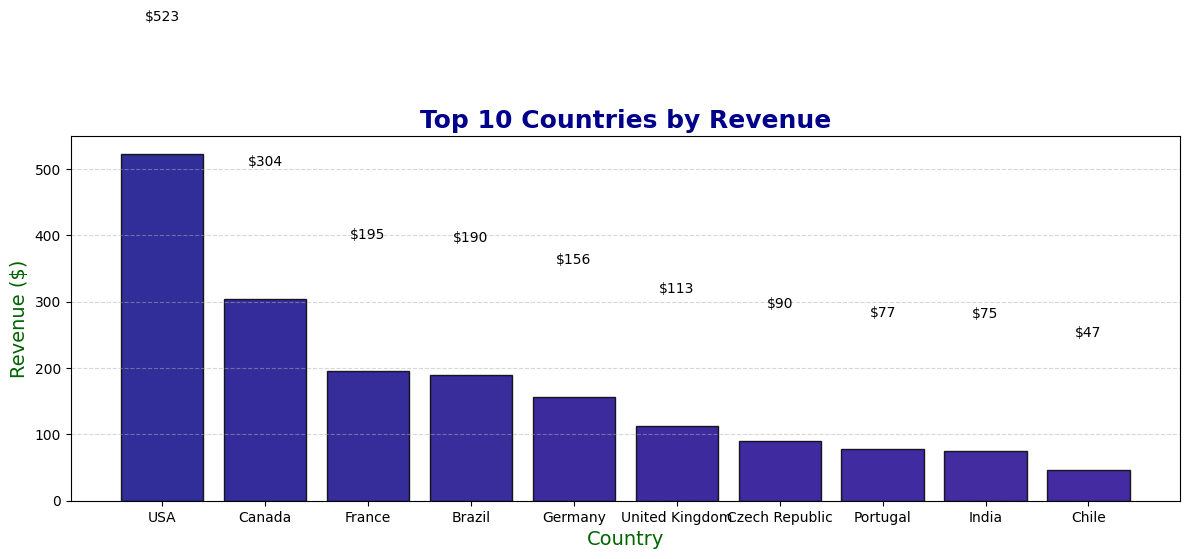

In [20]:
sql_country_revenue = """
SELECT 
    i.BillingCountry AS country,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS revenue
FROM InvoiceLine il
JOIN Invoice i ON il.InvoiceId = i.InvoiceId
GROUP BY i.BillingCountry
ORDER BY revenue DESC
LIMIT 10;
"""


df_country = pd.read_sql_query(sql_country_revenue, conn)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    df_country['country'], 
    df_country['revenue'], 
    color=plt.cm.plasma(range(len(df_country))),  
    edgecolor="black", alpha=0.85
)

plt.title("Top 10 Countries by Revenue", fontsize=18, fontweight="bold", color="darkblue")
plt.xlabel("Country", fontsize=14, color="darkgreen")
plt.ylabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"${bar.get_height():,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


# Revenue per Billing Country (Region)


In [ ]:
sql = """
SELECT
  i.BillingCountry AS country,
  ROUND(SUM(i.Total), 2) AS revenue
FROM Invoice i
GROUP BY i.BillingCountry
ORDER BY revenue DESC;
"""


df_region = run(sql)
df_region.head(10)  # preview top 10


,country,revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


##  Revenue by Country (Top 15 Regions)


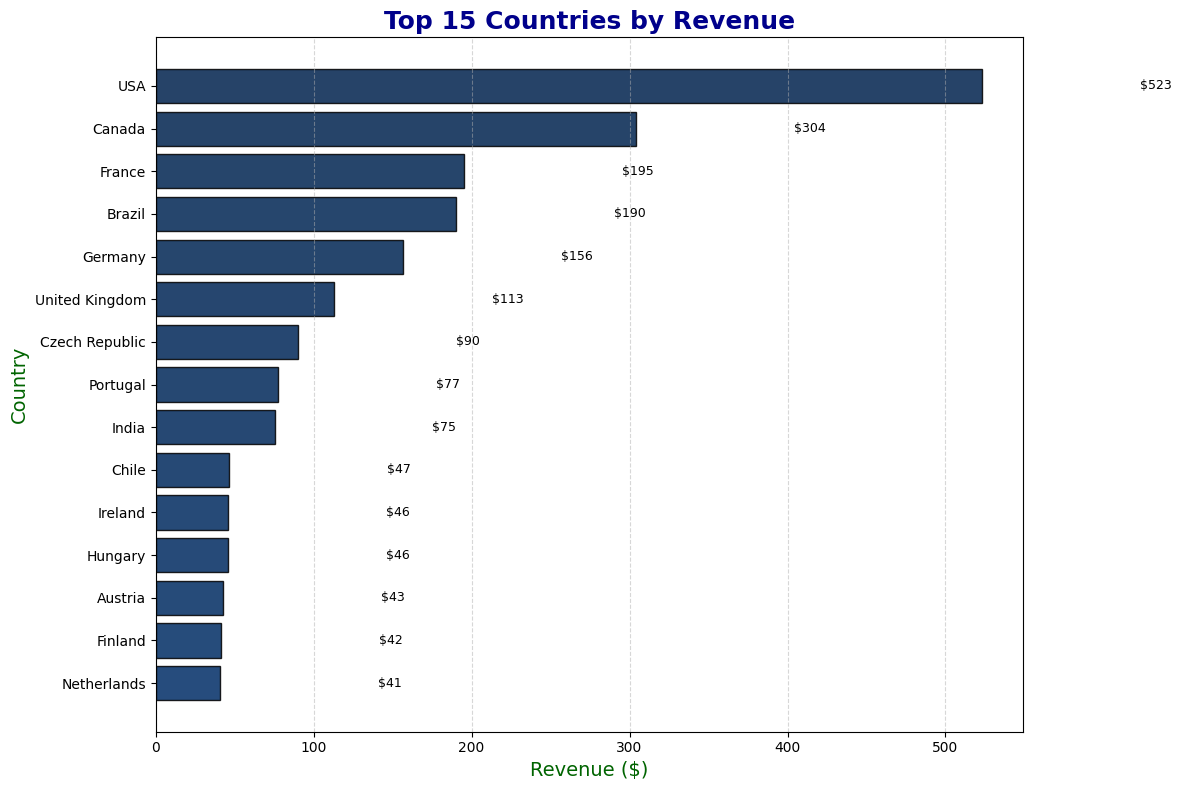

In [24]:

top_countries = df_region.sort_values(by="revenue", ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    top_countries['country'], 
    top_countries['revenue'], 
    color=plt.cm.cividis(range(len(top_countries))),
    edgecolor="black", alpha=0.85
)

plt.gca().invert_yaxis()


plt.title("Top 15 Countries by Revenue", fontsize=18, fontweight="bold", color="darkblue")
plt.xlabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.ylabel("Country", fontsize=14, color="darkgreen")
plt.grid(axis='x', linestyle='--', alpha=0.5)


for bar in bars:
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"${bar.get_width():,.0f}", va='center', fontsize=9, color="black")

plt.tight_layout()
plt.show()


# Monthly Revenue Performance


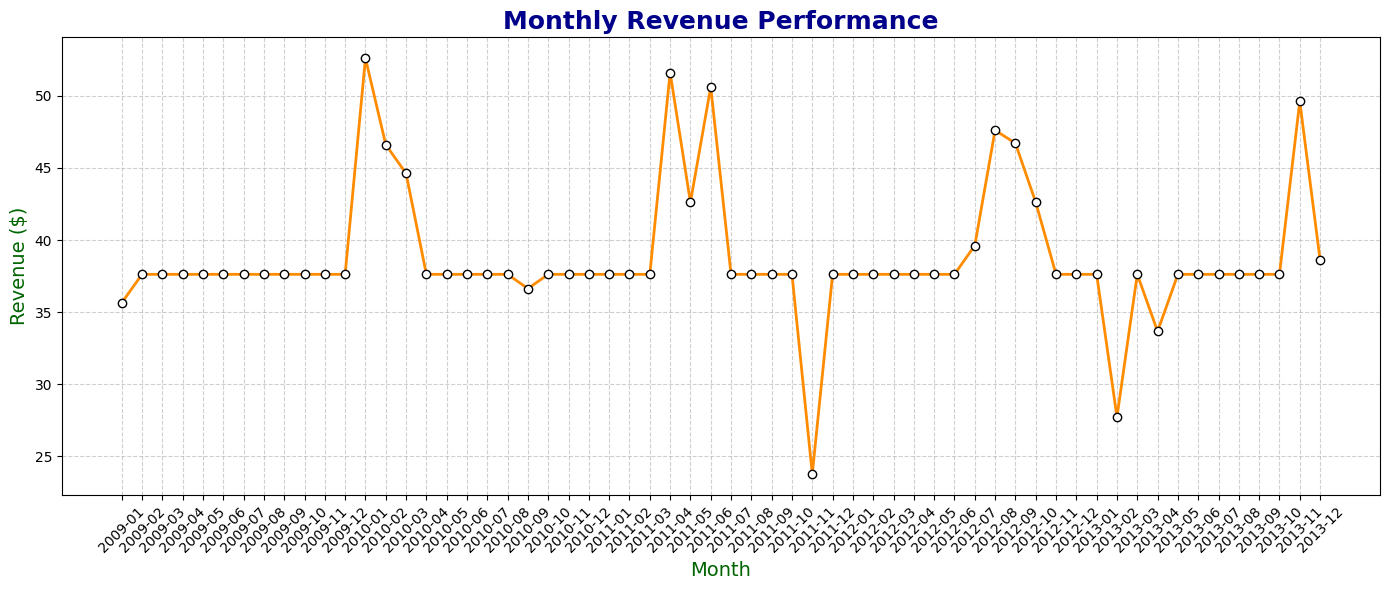

In [26]:
sql = """
SELECT
  strftime('%Y-%m', i.InvoiceDate) AS year_month,
  ROUND(SUM(i.Total), 2) AS revenue
FROM Invoice i
GROUP BY strftime('%Y-%m', i.InvoiceDate)
ORDER BY year_month;
"""
df_monthly = run(sql)

plt.figure(figsize=(14, 6))
plt.plot(df_monthly['year_month'], df_monthly['revenue'],
         marker='o', linestyle='-', linewidth=2,
         color='darkorange', markerfacecolor='white', markeredgecolor='black')

plt.title("Monthly Revenue Performance", fontsize=18, fontweight="bold", color="darkblue")
plt.xlabel("Month", fontsize=14, color="darkgreen")
plt.ylabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Revenue by Artist per Month (Using JOIN-heavy View)


In [27]:
sql = """
CREATE VIEW IF NOT EXISTS v_sales_product AS
SELECT
  il.InvoiceLineId,
  i.InvoiceId,
  i.InvoiceDate,
  i.BillingCountry,
  c.CustomerId,
  c.FirstName || ' ' || c.LastName AS customer_name,
  t.TrackId,
  t.Name AS track_name,
  g.Name AS genre_name,
  a.AlbumId,
  a.Title AS album_title,
  ar.ArtistId,
  ar.Name AS artist_name,
  il.UnitPrice,
  il.Quantity,
  (il.UnitPrice * il.Quantity) AS line_revenue
FROM InvoiceLine il
JOIN Invoice  i  ON i.InvoiceId  = il.InvoiceId
JOIN Customer c  ON c.CustomerId = i.CustomerId
JOIN Track    t  ON t.TrackId    = il.TrackId
LEFT JOIN Genre g ON g.GenreId   = t.GenreId
JOIN Album    a  ON a.AlbumId    = t.AlbumId
JOIN Artist   ar ON ar.ArtistId  = a.ArtistId;
"""
cur = conn.cursor()
cur.executescript(sql)
conn.commit()

sql_view_use = """
SELECT
  strftime('%Y-%m', InvoiceDate) AS year_month,
  artist_name,
  ROUND(SUM(line_revenue), 2) AS revenue
FROM v_sales_product
GROUP BY year_month, artist_name
ORDER BY year_month, revenue DESC;
"""
df_artist_monthly = run(sql_view_use)
df_artist_monthly.head(10)


,year_month,artist_name,revenue
0,2009-01,AC/DC,5.94
1,2009-01,Aerosmith,3.96
2,2009-01,Audioslave,2.97
3,2009-01,Caetano Veloso,1.98
4,2009-01,Body Count,1.98
5,2009-01,Black Sabbath,1.98
6,2009-01,Black Label Society,1.98
7,2009-01,Apocalyptica,1.98
8,2009-01,Antônio Carlos Jobim,1.98
9,2009-01,Alice In Chains,1.98


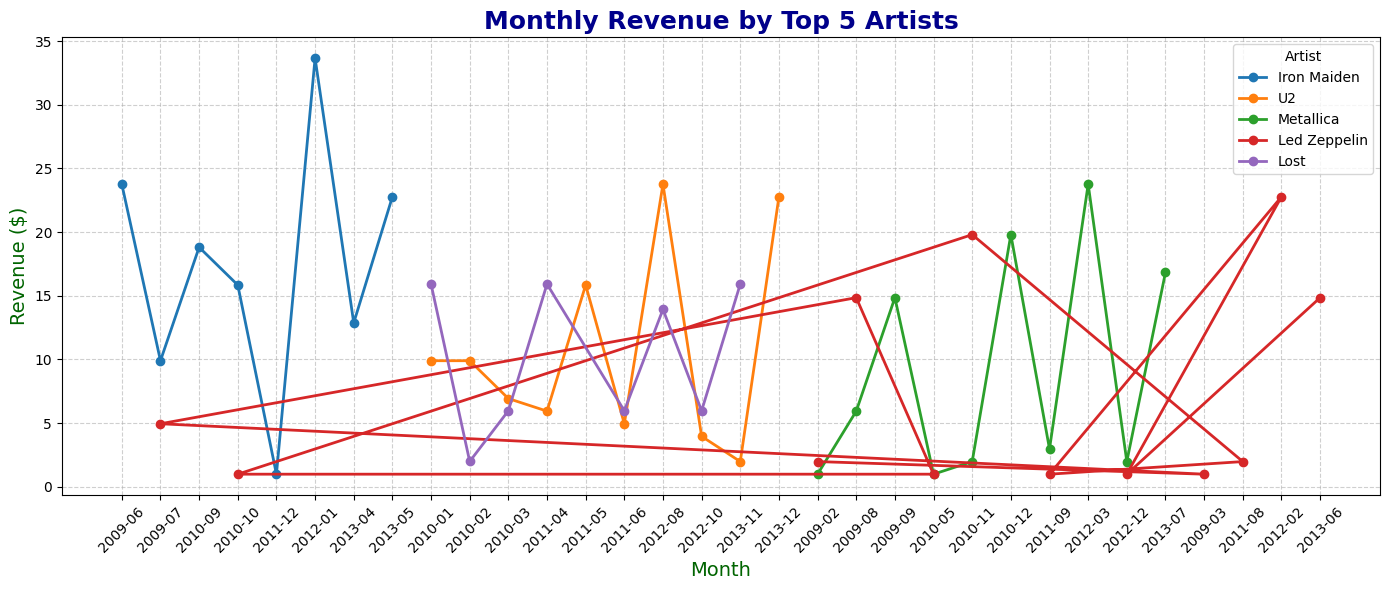

In [30]:
top_artists = df_artist_monthly.groupby("artist_name")["revenue"].sum().nlargest(5).index
df_filtered = df_artist_monthly[df_artist_monthly["artist_name"].isin(top_artists)]

plt.figure(figsize=(14, 6))
for artist in top_artists:
    artist_data = df_filtered[df_filtered["artist_name"] == artist]
    plt.plot(artist_data["year_month"], artist_data["revenue"],
             marker='o', linewidth=2, label=artist)

plt.title("Monthly Revenue by Top 5 Artists", fontsize=18, fontweight="bold", color="darkblue")
plt.xlabel("Month", fontsize=14, color="darkgreen")
plt.ylabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.xticks(rotation=45)
plt.legend(title="Artist", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


#   `Bonus`

#  Top 3 Tracks per Country `Window Function`


In [31]:
sql = """
WITH track_country AS (
  SELECT
    i.BillingCountry AS country,
    t.TrackId,
    t.Name AS track_name,
    SUM(il.UnitPrice * il.Quantity) AS revenue
  FROM InvoiceLine il
  JOIN Invoice i ON i.InvoiceId = il.InvoiceId
  JOIN Track t   ON t.TrackId   = il.TrackId
  GROUP BY i.BillingCountry, t.TrackId, t.Name
),
ranked AS (
  SELECT
    country,
    TrackId,
    track_name,
    revenue,
    RANK() OVER (PARTITION BY country ORDER BY revenue DESC) AS rnk
  FROM track_country
)
SELECT country, track_name, ROUND(revenue, 2) AS revenue, rnk
FROM ranked
WHERE rnk <= 3
ORDER BY country, rnk, track_name;
"""
df_bonus = run(sql)
df_bonus.head(15)


,country,track_name,revenue,rnk
0,Argentina,Battery,0.99,1
1,Argentina,Better Than You,0.99,1
2,Argentina,Cabeça Dinossauro,0.99,1
3,Argentina,Canário Do Reino,0.99,1
4,Argentina,Chemical Wedding,0.99,1
5,Argentina,Comida,0.99,1
6,Argentina,Compadre,0.99,1
7,Argentina,Deuce,0.99,1
8,Argentina,Disposable Heroes,0.99,1
9,Argentina,Dujji,0.99,1


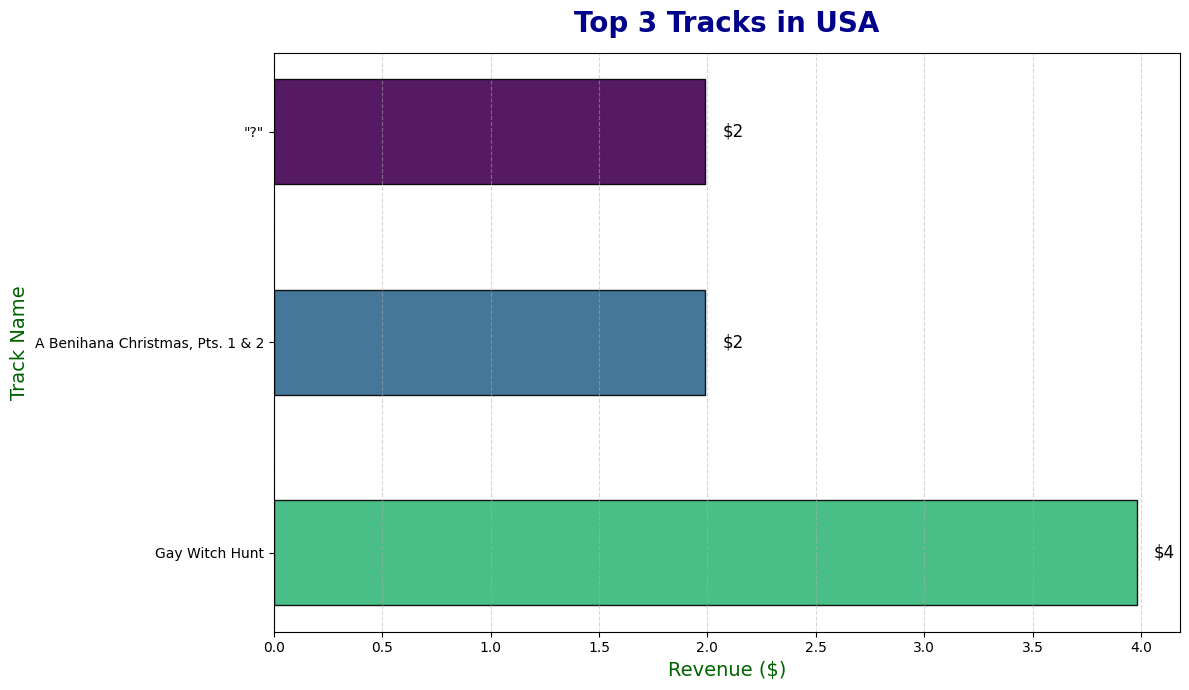

In [40]:
import matplotlib.pyplot as plt

country_select = "USA"  # change to any country

df_country_top3 = (
    df_bonus[df_bonus['country'] == country_select]
    .nlargest(3, 'revenue')
    .sort_values('revenue', ascending=True)  
)

plt.figure(figsize=(12, 7))  


colors = plt.cm.viridis(
    [i/len(df_country_top3) for i in range(len(df_country_top3))]
)

bars = plt.barh(
    df_country_top3['track_name'],
    df_country_top3['revenue'],
    color=colors,
    edgecolor="black", alpha=0.9, height=0.5  
)

plt.gca().invert_yaxis()  

plt.title(f"Top 3 Tracks in {country_select}", fontsize=20, fontweight="bold", color="darkblue", pad=15)
plt.xlabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.ylabel("Track Name", fontsize=14, color="darkgreen")
plt.grid(axis='x', linestyle='--', alpha=0.5)


for bar in bars:
    plt.text(
        bar.get_width() + (0.02 * max(df_country_top3['revenue'])), 
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va="center", fontsize=12, color="black"
    )

plt.tight_layout()
plt.show()



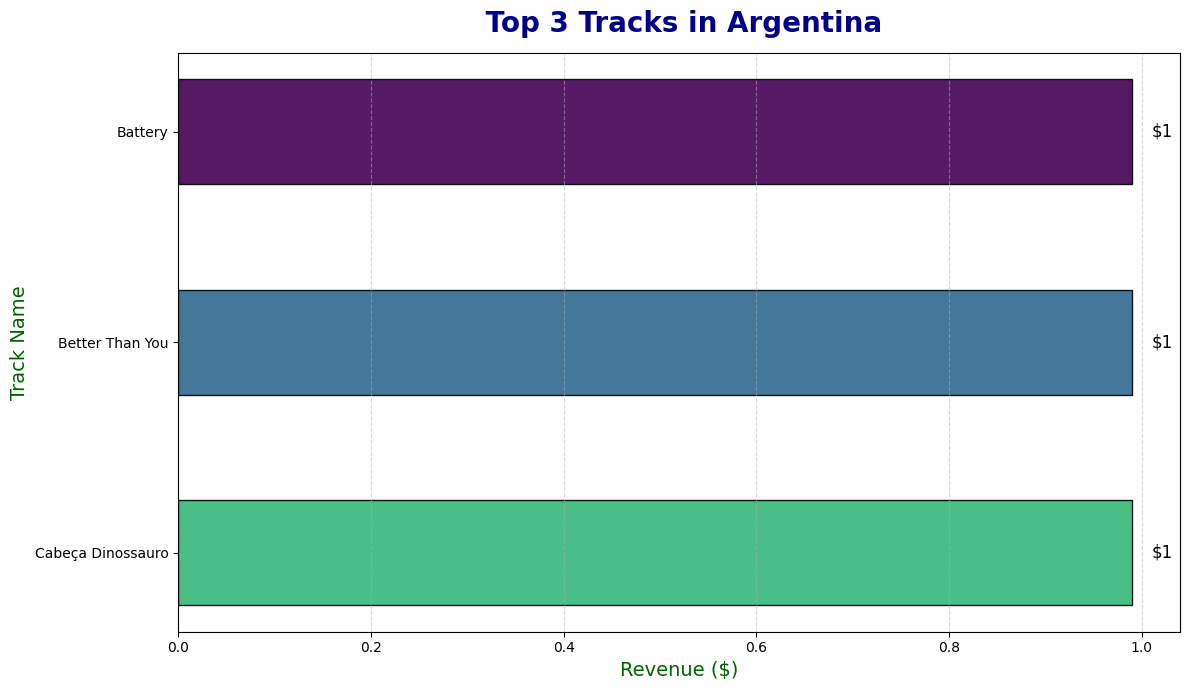

In [42]:
import matplotlib.pyplot as plt

country_select = "Argentina"  # change to any country

df_country_top3 = (
    df_bonus[df_bonus['country'] == country_select]
    .nlargest(3, 'revenue')
    .sort_values('revenue', ascending=True)  
)

plt.figure(figsize=(12, 7))  


colors = plt.cm.viridis(
    [i/len(df_country_top3) for i in range(len(df_country_top3))]
)

bars = plt.barh(
    df_country_top3['track_name'],
    df_country_top3['revenue'],
    color=colors,
    edgecolor="black", alpha=0.9, height=0.5  
)

plt.gca().invert_yaxis()  

plt.title(f" Top 3 Tracks in {country_select}", fontsize=20, fontweight="bold", color="darkblue", pad=15)
plt.xlabel("Revenue ($)", fontsize=14, color="darkgreen")
plt.ylabel("Track Name", fontsize=14, color="darkgreen")
plt.grid(axis='x', linestyle='--', alpha=0.5)


for bar in bars:
    plt.text(
        bar.get_width() + (0.02 * max(df_country_top3['revenue'])), 
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va="center", fontsize=12, color="black"
    )

plt.tight_layout()
plt.show()


#  Summary: Top 3 Tracks per Country

The window function analysis highlights the **most popular tracks across different countries**.  
By ranking tracks within each country based on revenue, we can see:

- **Local preferences differ significantly** — the top tracks in the USA are not the same as in Brazil or Canada.  
- In most regions, a few tracks dominate sales, showing a **concentration of demand**.  
- This insight can guide **regional marketing strategies**, helping focus promotions on tracks that resonate most with each market.  

 Overall, the use of **window functions** makes it easy to rank tracks within each country, providing a clear view of **regional hits** and **potential growth opportunities**.
